In [1]:
import sys
import pandas as pd
import numpy as np

sys.path.append('../../evaluation_utils/')
from evaluation import evaluation_func as fp_eval

from collections import OrderedDict

In [2]:
color_dict = OrderedDict()

color_dict["Methods"] = OrderedDict({
    "FedProt":"black",
    "Fisher":"#D44400",
    "Stouffer":"#E69F00",
    "REM":"#2E5EAA",
    "RankProd":"#009E73"
})

# Read results

In [3]:
dfs = {}

workdir = "/home/yuliya/repos/cosybio/FedProt/evaluation/" 
df = fp_eval.read_results(
    workdir,
    deqms_name="bacterial_data_protocols/results/central_res.tsv",
    fedprot_name="bacterial_data_protocols/results/DPE.csv",
    fisher_name="bacterial_data_protocols/results/MA_CM.tsv",
    rem_name="bacterial_data_protocols/results/MA_REM.tsv",
    stouffer_name="bacterial_data_protocols/results/MA_Stouffer.tsv",   
    rankprod_name="bacterial_data_protocols/results/MA_RankProd.tsv"
)
dfs["Bacterial dataset, NON-uniform vs uniform preprocessing"] = df
print(f"Proteins: {len(df)}")


Results loaded for DEqMS with 2863 proteins.
Results loaded for FedProt with 2928 proteins.
Results loaded for Fisher with 2870 proteins.
Results loaded for REM with 3097 proteins.
Results loaded for Stouffer with 2304 proteins.
Results loaded for RankProd with 3097 proteins.
Results loaded from /home/yuliya/repos/cosybio/FedProt/evaluation/ with 2304 genes. Adj.p-values were not log-transformed.


Proteins: 2304


In [4]:
log_dfs = {}
for k in dfs:
    df = dfs[k]
    df = df.replace(0,1e-300)
    # df["pv_DEqMS"] = -np.log10(df["pv_DEqMS"])
    for m in ["DEqMS", "FedProt", "Fisher","Stouffer","REM","RankProd"]:
        df.loc[df["pv_"+m] < 1e-300, "pv_"+m] = 1e-300
        df.loc[:, "pv_"+m] = -np.log10(df["pv_"+m])
    log_dfs[k] = df

# Stats calculation

In [5]:
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/bacterial_data_protocols/"

for dataset in log_dfs:

    pval_basic_stats = fp_eval.calc_stats(
        log_dfs[dataset], 
        lfc_thr=0.58, adj_pval_thr=0.01,
        stats=["MeanDiff", "MaxDiff"],
        methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
        column_name="pv_",
        top_genes=-1
    )
    logfc_basic_stats = fp_eval.calc_stats(
        log_dfs[dataset],
        lfc_thr=0.58, adj_pval_thr=0.01,
        stats=["MeanDiff", "MaxDiff"],
        methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
        column_name="lfc_",
        top_genes=-1
    )

    pval_basic_stats.to_csv(f'{root_dir}/tables/{dataset}_pval_basic_stats.csv')
    logfc_basic_stats.to_csv(f'{root_dir}/tables/{dataset}_logfc_basic_stats.csv')

    print(f'Dataset: {dataset}')
    print("\tLogFC basic stats:")
    print(logfc_basic_stats)
    print("\tP-value basic stats:")
    print(pval_basic_stats)        

Dataset: Bacterial dataset, NON-uniform vs uniform preprocessing
	LogFC basic stats:
          MeanDiff   MaxDiff
FedProt   0.077382  1.525883
Fisher    0.077603  1.550228
Stouffer  0.077603  1.550228
REM       0.075269  1.376904
RankProd  0.077603  1.550228
	P-value basic stats:
           MeanDiff     MaxDiff
FedProt    2.476691   29.932268
Fisher     4.421263   39.699522
Stouffer   4.170221   41.702840
REM       17.145112  264.318290
RankProd  13.241104   79.724806


In [6]:
# shorter version of log_dfs taking only 50% of rows randomly
short_log_dfs = {}
for dataset in log_dfs:
    short_log_dfs[dataset] = log_dfs[dataset].sample(frac=0.25, random_state=1)
    print(f"Dataset: {dataset}, proteins: {len(short_log_dfs[dataset])}")

Dataset: Bacterial dataset, NON-uniform vs uniform preprocessing, proteins: 576


Plotting correlation using p-vals - log-transformed.


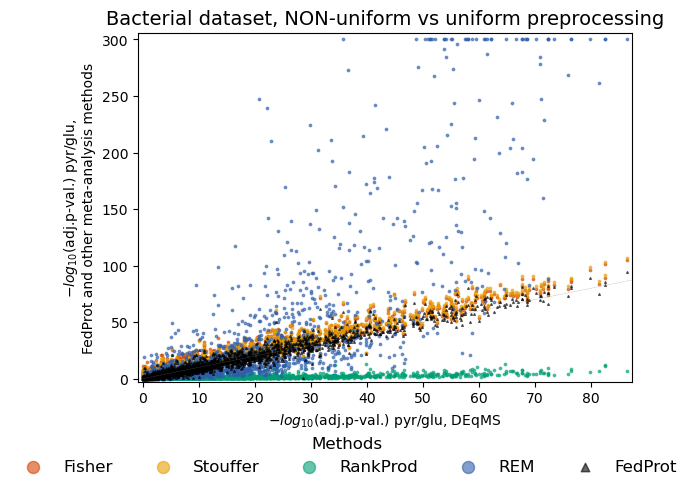

In [7]:
plot_one = fp_eval.plt_results(
    log_dfs, 
    methods=["Fisher", "Stouffer", "RankProd", "REM", "FedProt"],
    color_dict=color_dict,
    what="pv_", 
    text="", dotsize=3,
    datasets=list(log_dfs.keys()),
    figsize=(6,4.5),
    add_table=False,
    sharex=False, sharey=False,
    comparsions=["pyr/glu", "control/FSGS"],
    bbox_to_anchor_param=(0.5, -0.1)
)

# plt.savefig("/home/yuliya/repos/cosybio/FedDEqMS/data/04_evaluation/plots/" + "Fig3B_prototype.png", dpi=1200)

Plotting correlation using logFC values.


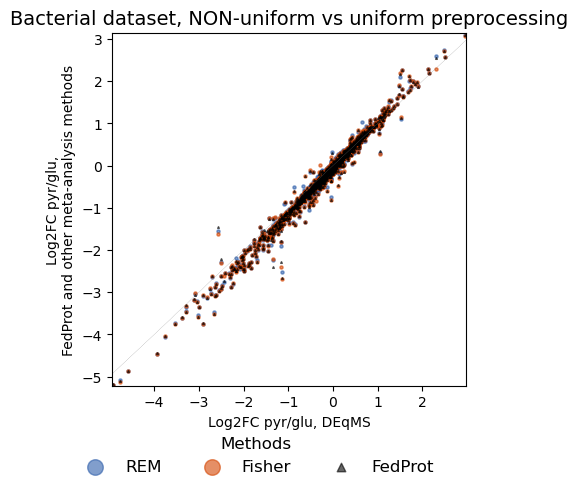

In [8]:
_ = fp_eval.plt_results(
    log_dfs, 
    methods=["REM", "Fisher", "FedProt"],
    color_dict=color_dict,
    what="lfc_", 
    text="", dotsize=5,
    figsize=(4.5,4.5),
    datasets=list(log_dfs.keys()),
    add_table=False,
    sharex =False, sharey=False,
    comparsions=["pyr/glu", "control/FSGS"],
    # set_lims = [[-2,2], [-0.8, 0.8]],
    bbox_to_anchor_param=(0.5, -0.1)
)

# plt.savefig("/home/yuliya/repos/cosybio/FedDEqMS/data/04_evaluation/plots/" + "Fig3B_prototype.png", dpi=1200)

# Top lists

In [9]:
fp_fn_b = fp_eval.calc_stats(
    log_dfs["Bacterial dataset, NON-uniform vs uniform preprocessing"], 
    lfc_thr=0.5, adj_pval_thr=0.05,
    stats=["FP", "FN", "Jaccard"],
    methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
    column_name="pv_",
    top_genes=-1
)
fp_fn_b.to_csv(f'{root_dir}/tables/Bacterial_FP_FN.csv')
# for Jaccard column, round to 3 decimal places
fp_fn_b["Jaccard"] = fp_fn_b["Jaccard"].round(3)

print("\tFP/FN bacterial dataset:")
print(fp_fn_b)  

	FP/FN bacterial dataset:
            FP     FN  Jaccard
FedProt   94.0   10.0    0.857
Fisher    95.0   10.0    0.855
Stouffer  95.0   10.0    0.855
REM       95.0   13.0    0.851
RankProd  22.0  124.0    0.776


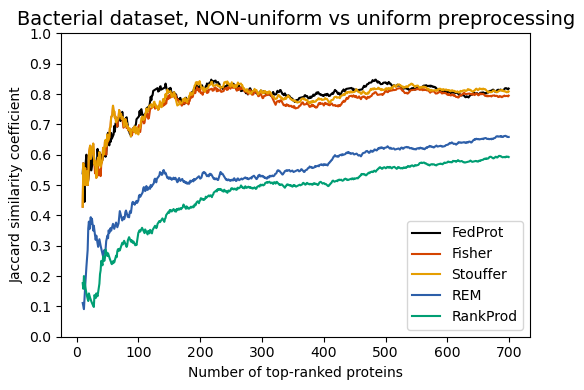

In [13]:
min_n_genes = 10
step = 1

_, _ = fp_eval.plot_stats_for_topN(
    log_dfs,
    datasets = list(log_dfs.keys()),
    methods=["FedProt", "Fisher","Stouffer","REM", "RankProd"],
    metrics=["Jaccard"],
    min_n_genes=min_n_genes,
    max_n_genes=[700, 300],
    figsize=(5.5,4),
    step=step,
    color_dict=color_dict,
    sharey=False,
    )